In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

# 1. Define Transformation (Images must be converted to Tensors and Normalized)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Mean and Std for MNIST
])

# 2. Download and Load
train_set = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Successfully loaded {len(train_set)} training images!")

Successfully loaded 60000 training images!


In [2]:
import torch

def corr2d(X, K):
    """
    X: Input image matrix
    K: Kernel (filter)
    """
    h, w = K.shape
    # Output size formula: (Input_H - Kernel_H + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # The heart of CNN: Multiply and Sum
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

# TEST IT: Create a small example for your report
# Imagine X is a 3x3 image and K is a 2x2 edge detector
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])

print("Manual Correlation Result:\n", corr2d(X, K))

Manual Correlation Result:
 tensor([[19., 25.],
        [37., 43.]])


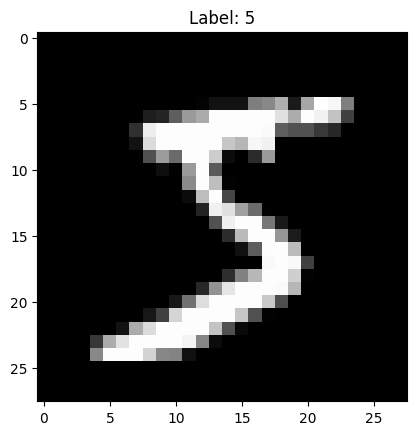

In [3]:
import matplotlib.pyplot as plt

# Get the first image from the dataset
image, label = train_set[0]

plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [4]:
import torch

def corr2d(X, K):
    """
    X: Input image matrix
    K: Kernel (the filter)
    """
    h, w = K.shape
    # Output size formula: (Input_H - Kernel_H + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # The core of CNN: Element-wise multiply then sum
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

# Test with a dummy edge detector for your report
X_dummy = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K_dummy = torch.tensor([[0.0, 1.0], [2.0, 3.0]])

print("Manual Correlation Result:\n", corr2d(X_dummy, K_dummy))

Manual Correlation Result:
 tensor([[19., 25.],
        [37., 43.]])


In [5]:
import torch

def manual_conv2d(X, K):
    """
    X: The image grid
    K: The scanner (kernel)
    """
    h, w = K.shape
    # Calculate output size: (Input - Kernel + 1)
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # Multiply the scanner by the image patch and sum it up
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
    return Y

# TEST: Let's use a 3x3 grid and a 2x2 scanner
X_test = torch.tensor([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
K_test = torch.tensor([[0, 1], [2, 3]])
print("Manual Convolution Result:\n", manual_conv2d(X_test, K_test))

Manual Convolution Result:
 tensor([[19., 25.],
        [37., 43.]])


In [6]:


import torch.nn as nn
import torch.nn.functional as F

class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        # Layer 1: Convolution (Scans for 6 different types of edges)
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5) 
        # Layer 2: Pooling (Shrinks the image to make it simpler)
        self.pool = nn.MaxPool2d(2, 2)
        # Layer 3: Second Convolution (Scans for more complex shapes)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        
        # The MLP Part (The "Decision Maker" from Phase 1)
        # We flatten the image into a line before these layers
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10) # 10 outputs for digits 0-9

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4) # Flattening the "image" into a "line"
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Create the model and move it to your CPU/GPU
model = MyCNN()
print(model)

MyCNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [7]:
import torch.nn as nn

# 1. The Loss Function (How the model measures its mistakes)
# CrossEntropyLoss is perfect for multi-class tasks like 0-9 digits
criterion = nn.CrossEntropyLoss()

# 2. The Optimizer (The engine that updates the model's weights)
# We use Adam because it's fast and usually works better than standard SGD
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Optimizer and Criterion are now defined!")

Optimizer and Criterion are now defined!


In [8]:
import time

epochs = 5
model.train() # Set model to training mode

start_time = time.time()

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # 1. Zero the parameter gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 3. Backward pass (Backpropagation)
        loss.backward()

        # 4. Optimize (Update the weights)
        optimizer.step()

        running_loss += loss.item()
        
    print(f"Epoch {epoch + 1} - Loss: {running_loss / len(train_loader):.4f}")

print(f"Finished Training in {(time.time() - start_time)/60:.2f} minutes")

Epoch 1 - Loss: 0.2317
Epoch 2 - Loss: 0.0667
Epoch 3 - Loss: 0.0479
Epoch 4 - Loss: 0.0390
Epoch 5 - Loss: 0.0328
Finished Training in 1.97 minutes


In [9]:
model.eval()  # Set model to evaluation mode (turns off dropout/batchnorm)
correct = 0
total = 0

with torch.no_grad(): # No need to calculate gradients during testing
    for data in test_loader:
        images, labels = data
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1) # Pick the highest probability
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f} %')

Accuracy of the network on the 10,000 test images: 99.00 %


In [10]:
torch.save(model.state_dict(), '../models/best_cnn_model.pth')

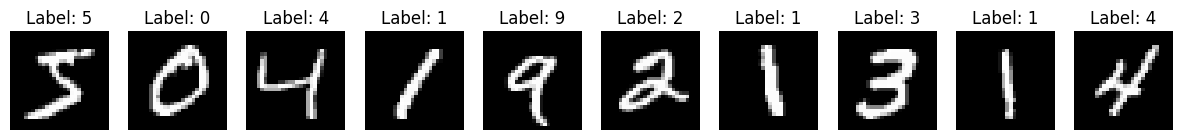

In [11]:
import matplotlib.pyplot as plt

# Create a figure to display 10 images
plt.figure(figsize=(15, 3))

for i in range(10):
    image, label = train_set[i]
    
    # Create a subplot for each image
    plt.subplot(1, 10, i + 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off') # Hide the x/y numbers for a cleaner look

plt.show()

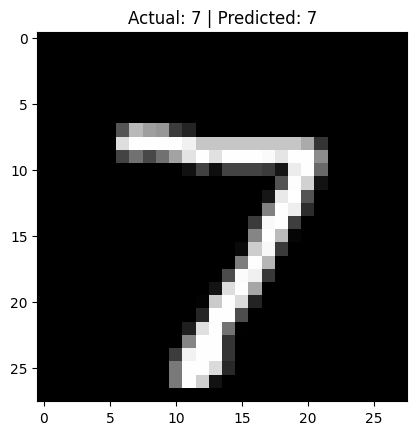

In [12]:
# Pick a random image from the test set
images, labels = next(iter(test_loader))
img = images[0]
label = labels[0]

# Make a prediction
model.eval()
with torch.no_grad():
    output = model(img.unsqueeze(0))
    _, predicted = torch.max(output, 1)

# Display result
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Actual: {label} | Predicted: {predicted.item()}")
plt.show()

In [13]:
import torch
import torch.nn as nn

# 1. Define the Custom MLP Class structure (Required for Phase I)
class CustomMLP(nn.Module):
    def __init__(self, input_dim=30, output_dim=2):  # Matches Breast Cancer features
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, output_dim)
        
    def forward(self, x):
        out = self.relu1(self.fc1(x))
        out = self.relu2(self.fc2(out))
        out = self.fc3(out)
        return out

# 2. Instantiate the model variable
mlp_custom = CustomMLP(input_dim=30, output_dim=2)

# 3. Define the mandatory initialization function
def initialize_weights(model, strategy='xavier'):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if strategy == 'gaussian':
                nn.init.normal_(param, mean=0.0, std=0.01)
            elif strategy == 'constant':
                nn.init.constant_(param, 0.1)
            elif strategy == 'xavier':
                if param.dim() >= 2:
                    nn.init.xavier_uniform_(param)
                else:
                    nn.init.normal_(param, mean=0.0, std=0.01)
        elif 'bias' in name:
            nn.init.constant_(param, 0.0)

# 4. Test the strategy (e.g., Xavier)
initialize_weights(mlp_custom, strategy='xavier')
print("Model created and weights successfully re-initialized using the Xavier Uniform strategy!")

Model created and weights successfully re-initialized using the Xavier Uniform strategy!


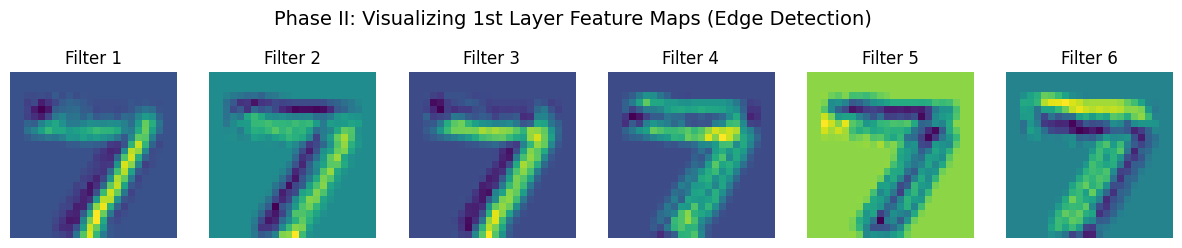

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Re-define the LeNet-style CNN architecture structure
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# 2. Instantiate the model variable locally
visualization_model = MyCNN()

# 3. Safely grab a single test image from your existing test_loader
images, labels = next(iter(test_loader))
single_img = images[0].unsqueeze(0)  # Shape: [1, 1, 28, 28]

# 4. Pass the image through ONLY the first convolution layer
visualization_model.eval()
with torch.no_grad():
    feature_maps = visualization_model.conv1(single_img)  # Shape: [1, 6, 24, 24]

# 5. Plot all 6 channels of feature maps extracted by Conv1
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for idx in range(6):
    axes[idx].imshow(feature_maps[0, idx].numpy(), cmap='viridis')
    axes[idx].set_title(f"Filter {idx+1}")
    axes[idx].axis('off')

plt.suptitle("Phase II: Visualizing 1st Layer Feature Maps (Edge Detection)", fontsize=14)
plt.show()